# Westcott $g$ factors

This `notebook` can be used to demonstrate methods available in the `westcott` Python library.

In [1]:
import westcott
gw = westcott.Westcott()
import numpy as np

In [2]:
# Find list of available targets
t=gw.find_targets()
print(*t)

Ac225 Ac226 Ac227 Ag107 Ag108 Ag109 Ag110_m1 Ag111 Ag112 Ag113 Ag114 Ag115 Ag116 Ag117 Ag118_m1 Al26_m1 Al27 Am240 Am241 Am242 Am242_m1 Am243 Am244 Am244_m1 Ar36 Ar37 Ar38 Ar39 Ar40 Ar41 As73 As74 As75 Au197 B10 B11 Ba130 Ba131 Ba132 Ba133 Ba134 Ba135 Ba136 Ba137 Ba138 Ba139 Ba140 Be9 Bi209 Bi210_m1 Bk245 Bk246 Bk247 Bk248 Bk249 Bk250 Br79 Br80 Br81 C12 C13 Ca40 Ca41 Ca42 Ca43 Ca44 Ca45 Ca46 Ca47 Ca48 Cd106 Cd107 Cd108 Cd109 Cd110 Cd111 Cd112 Cd113 Cd114 Cd115_m1 Cd116 Ce136 Ce137 Ce137_m1 Ce138 Ce139 Ce140 Ce141 Ce142 Ce143 Ce144 Cf246 Cf247 Cf248 Cf249 Cf250 Cf251 Cf252 Cf253 Cf254 Cl35 Cl36 Cl37 Cm240 Cm241 Cm242 Cm243 Cm244 Cm245 Cm246 Cm247 Cm248 Cm249 Cm250 Co58 Co58_m1 Co59 Cr50 Cr51 Cr52 Cr53 Cr54 Cs133 Cs134 Cs135 Cs136 Cs137 Cu63 Cu64 Cu65 Dy154 Dy155 Dy156 Dy157 Dy158 Dy159 Dy160 Dy161 Dy162 Dy163 Dy164 Er162 Er163 Er164 Er165 Er166 Er167 Er168 Er169 Er170 Es251 Es252 Es253 Es254 Es254_m1 Es255 Eu151 Eu152 Eu153 Eu154 Eu155 Eu156 Eu157 F19 Fe54 Fe55 Fe56 Fe57 Fe58 Fm255 Ga69

## Maxwellian distributions

In [3]:
# Get ENDF-B/VIII.1 cross section data
endf_e, endf_cs = gw.sigma_ENDF('Sm149')

In [4]:
# Evaluate g-factor based on Maxwellian distribution for various temperatures
T = [100,200,293,400,500,600]
print("Maxwellian g-factors")
for t in T:
    gW = gw.gw_Maxwellian(t, endf_e, endf_cs)
    print(f"T = {t} K: g = {gW}")

Maxwellian g-factors
T = 100 K: g = 0.800986123223094
T = 200 K: g = 1.2219248293391727
T = 293 K: g = 1.6789881668926454
T = 400 K: g = 2.0640280256603987
T = 500 K: g = 2.261523216071725
T = 600 K: g = 2.3419529444927147


In [5]:
# Repeat for 83Kr
endf_e, endf_cs = gw.sigma_ENDF('Kr83')
T = [100,200,293,400,500,600]
print("Maxwellian g-factors")
for t in T:
    gW = gw.gw_Maxwellian(t, endf_e, endf_cs)
    print(f"T = {t} K: g = {gW}")

Maxwellian g-factors
T = 100 K: g = 1.0026254862230148
T = 200 K: g = 1.000121189595491
T = 293 K: g = 0.9978021956639186
T = 400 K: g = 0.9951510524054634
T = 500 K: g = 0.9926898287861599
T = 600 K: g = 0.9902445804972184


## Ideal neutron guide distribution

In [6]:
# Evaluate g-factor based on Maxwellian distribution for various temperatures
T = [100,200,293,400,500,600]
print("Ideal guide g-factors")
for t in T:
    gW = gw.gw_IdealGuide(t, endf_e, endf_cs)
    print(f"T = {t} K: g = {gW}")

Ideal guide g-factors
T = 100 K: g = 0.9858624269312858
T = 200 K: g = 0.9904292122566654
T = 293 K: g = 0.9919191861577683
T = 400 K: g = 0.9925811044249164
T = 500 K: g = 0.9927248314252165
T = 600 K: g = 0.9926167182881678


## Experimental neutron flux distributions

In [7]:
# Find list of tuples corresponding to the available experimental spectra
gw.find_flux()

[(0, 'bnc_cold_spectrum_2002.csv'),
 (1, 'bnc_cold_spectrum_2012.csv'),
 (2, 'bnc_thermal_spectrum_2002.csv'),
 (3, 'frm-ii_cold_spectrum_2008.csv')]

In [8]:
# Get flux data for cold FRM-II spectrum
energy, cs = gw.get_flux(0)

In [9]:
# Evaluate g-factor based on cold FRM-II flux
endf_e, endf_cs = gw.sigma_ENDF('Sm149')
gW = gw.gw_arbitrary(energy, cs, endf_e, endf_cs)
print(f"FRM-II cold-neutron spectrum (21 K) g = {gW}")

FRM-II cold-neutron spectrum (21 K) g = 0.675721084379764


In [10]:
# Repeat for 83Kr 
endf_e, endf_cs = gw.sigma_ENDF('Kr83')
gW = gw.gw_arbitrary(energy, cs, endf_e, endf_cs)
print(f"FRM-II cold-neutron spectrum (21 K) g = {gW}")

FRM-II cold-neutron spectrum (21 K) g = 1.0035886785934107


In [11]:
# Get flux data for thermal BRR spectrum
energy, cs = gw.get_flux(1)

In [12]:
# Evaluate g-factor based on thermal BRR flux
endf_e, endf_cs = gw.sigma_ENDF('Sm149')
gW = gw.gw_arbitrary(energy, cs, endf_e, endf_cs)
print(f"BRR thermal-neutron spectrum (293 K) g = {gW}")

BRR thermal-neutron spectrum (293 K) g = 0.721093469216032


In [13]:
# Repeat for 83Kr 
endf_e, endf_cs = gw.sigma_ENDF('Kr83')
gW = gw.gw_arbitrary(energy, cs, endf_e, endf_cs)
print(f"BRR thermal-neutron spectrum (293 K) g = {gW}")

BRR thermal-neutron spectrum (293 K) g = 1.0035217014148992


## Resonance parameters from ENDF

In [14]:
# Find lists of targets with different types of resonance parametrizations
targs = gw.find_resonances()
print("All targets with resonance parameters:\n")
print(*targs)
bw = gw.find_resonances(res='BW')
print("\nTargets with Breit-Wigner resonance parameters:\n")
print(*bw)
rm = gw.find_resonances(res='RM')
print("\nTargets with Reich-Moore resonance parameters:\n")
print(*rm)

All targets with resonance parameters:

Ag107 Ag108 Ag109 Ag110_m1 Ag111 Ag112 Ag113 Ag114 Ag115 Ag116 Ag117 Ag118_m1 Al26_m1 Al27 Am241 Am242 Am242_m1 Am243 Ar36 Ar37 Ar38 Ar39 Ar40 Ar41 As73 As74 As75 Au197 Ba130 Ba131 Ba132 Ba133 Ba134 Ba135 Ba136 Ba137 Ba138 Ba139 Ba140 Bi209 Bi210_m1 Bk249 Br79 Br80 Br81 Ca40 Ca41 Ca42 Ca43 Ca44 Ca45 Ca47 Ca48 Cd106 Cd107 Cd108 Cd109 Cd110 Cd111 Cd112 Cd113 Cd114 Cd115_m1 Cd116 Ce136 Ce137 Ce137_m1 Ce138 Ce139 Ce140 Ce141 Ce142 Ce143 Cf247 Cf249 Cf250 Cf251 Cf252 Cl35 Cl36 Cl37 Cm242 Cm243 Cm244 Cm245 Cm246 Cm247 Cm248 Cm250 Co58 Co58_m1 Co59 Cr50 Cr51 Cr52 Cr53 Cr54 Cs133 Cs134 Cs135 Cu63 Cu64 Cu65 Dy155 Dy156 Dy157 Dy158 Dy160 Dy161 Dy162 Dy163 Dy164 Er162 Er163 Er164 Er165 Er166 Er167 Er168 Er169 Er170 Es253 Eu151 Eu152 Eu153 Eu154 Eu155 Eu157 Fe54 Fe55 Fe56 Fe57 Fe58 Ga69 Ga70 Ga71 Gd152 Gd153 Gd154 Gd155 Gd156 Gd157 Gd158 Gd159 Gd160 Ge70 Ge71 Ge72 Ge73 Ge74 Ge75 Ge76 Hf174 Hf175 Hf176 Hf177 Hf178 Hf179 Hf180 Hg196 Hg197 Hg197_m1 Hg198 Hg199 

### Irregularity: Breit-Wigner

In [15]:
# Get resonance parameters for Breit-Wigner 83Kr
target_bw = 'Kr83'
res_bw = gw.get_res_paras(target_bw)
res_bw

,energy,L,J,totalWidth,neutronWidth,captureWidth
0,-9.81,0,5.0,0.384000,0.084000,0.300
1,28.05,0,5.0,0.267222,0.052222,0.215
2,229.20,0,4.0,0.522200,0.322200,0.200


In [16]:
# Extract first resonance needed for irregularity approximation
res_array = res_bw.to_numpy()
res_e = res_array[0][0]
res_width_tot = res_array[0][3]
print(f"Energy of first resonance = {res_e} eV")
print(f"Total width first resonance = {res_width_tot}")

Energy of first resonance = -9.81 eV
Total width first resonance = 0.384


In [17]:
# Calculate Westcott g-factor based on irregularity approximation for various temperatures
T = [100,200,293,400,500,600]
print("Irregularity g-factors")
for t in T:
    gW = gw.gw_irregularity(res_e, res_width_tot, t)
    print(f"T = {t} K: g = {gW}")

Irregularity g-factors
T = 100 K: g = 1.002523308835928
T = 200 K: g = 0.9999013539204072
T = 293 K: g = 0.997478210916762
T = 400 K: g = 0.9947082872062649
T = 500 K: g = 0.9921367711130005
T = 600 K: g = 0.9895816700353778


<Axes: xlabel='energy'>

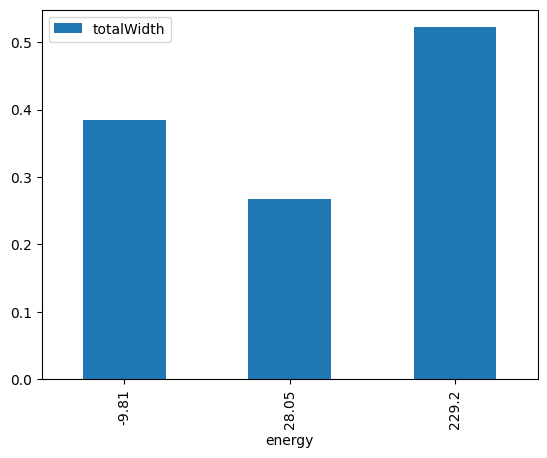

In [18]:
# Create simple bar plot of resonances from DataFrame
res_bw.plot(x='energy', y='totalWidth', kind='bar')

In [19]:
# Dump DataFrame to CSV
res_bw.to_csv("resonances_bw_{0}.csv".format(target_bw), index=False)

### Irregularity: Reich-Moore

In [20]:
# Get resonance parameters for Reich-Moore 157Gd
target_rm = 'Gd157'
res_rm = gw.get_res_paras(target_rm)
res_rm

,energy,Gd158 + photon [inclusive] width,n + Gd157 width,J,Pi,L
24,0.0314,0.107200,0.000474,2,1,0
25,2.8250,0.097000,0.000345,2,1,0
0,16.2400,0.091000,0.000400,1,1,0
26,16.7700,0.080500,0.012800,2,1,0
27,20.5600,0.088000,0.011360,2,1,0
28,21.6500,0.114000,0.000376,2,1,0
1,23.3300,0.121000,0.000813,1,1,0
29,25.4000,0.085000,0.001840,2,1,0
2,40.1700,0.110000,0.001307,1,1,0
30,44.2200,0.096000,0.008960,2,1,0


In [21]:
# Extract first resonance needed for irregularity approximation
res_array = res_rm.to_numpy()
res_e = res_array[0][0]
res_width_tot = res_array[0][1]+res_array[0][2]
print(f"Energy of first resonance = {res_e} eV")
print(f"Total width first resonance = {res_width_tot}")

Energy of first resonance = 0.0314 eV
Total width first resonance = 0.107674


In [22]:
# Calculate Westcott g-factor based on irregularity approximation for various temperatures
T = [100,200,293,400,500,600]
print("Irregularity g-factors")
for t in T:
    gW = gw.gw_irregularity(res_e, res_width_tot, t)
    print(f"T = {t} K: g = {gW}")

Irregularity g-factors
T = 100 K: g = 0.8825346091020468
T = 200 K: g = 0.8978990546543921
T = 293 K: g = 0.8534118818655398
T = 400 K: g = 0.7815175845592797
T = 500 K: g = 0.713345927736361
T = 600 K: g = 0.6505185000417292


In [23]:
# Use regex methods to determine 'A+1' compound system
import re
letters_pattern = '\D+'
numbers_pattern = '\d+'
chem_symbol = str(re.findall(letters_pattern, target_rm)[0])
mass = int(re.findall(numbers_pattern, target_rm)[0])
compound_mass = mass + 1
compound = str(chem_symbol+str(compound_mass))
print(f"{target_rm} + n -> {compound}")

Gd157 + n -> Gd158


<>:3: SyntaxWarning: invalid escape sequence '\D'
<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\D'
<>:4: SyntaxWarning: invalid escape sequence '\d'
/var/folders/cp/1zwsykc55px6rmp4395l06f40000gn/T/ipykernel_37536/1232680767.py:3: SyntaxWarning: invalid escape sequence '\D'
  letters_pattern = '\D+'
/var/folders/cp/1zwsykc55px6rmp4395l06f40000gn/T/ipykernel_37536/1232680767.py:4: SyntaxWarning: invalid escape sequence '\d'
  numbers_pattern = '\d+'


<Axes: xlabel='energy', ylabel='totalWidth'>

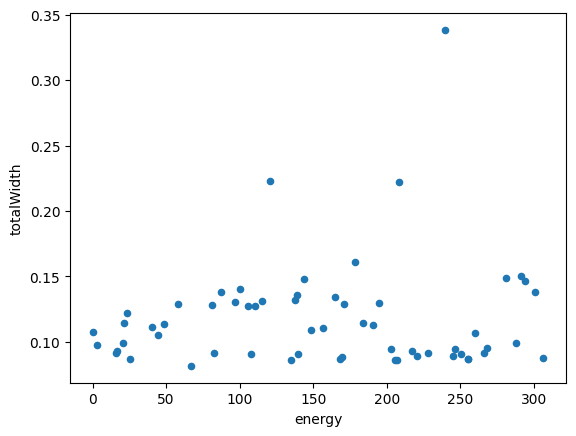

In [24]:
# Combine DataFrame columns to calculate total witdth then create simple scatter plot of resonances from DataFrame
res_rm['totalWidth'] = res_rm[f'{compound} + photon [inclusive] width'] + res_rm[f'n + {target_rm} width']
res_rm.plot(x='energy',y='totalWidth',kind='scatter')

In [25]:
# Dump DataFrame to CSV with 'totalWidth' in final column
res_rm.to_csv("resonances_rm_{0}.csv".format(target_rm), index=False)

## Inspect ENDF neutron-capture cross-section data

In [26]:
import matplotlib.pyplot as plt
import re

In [27]:
def plot_MT102(df,target,energy_units='eV',cs_units='b',save=False):
    """Function to plot the ENDF neutron-capture cross-section data corresponding to MT=102."""    
    letters_pattern = '\D+'
    numbers_pattern = '\d+'
    chem_symbol = str(re.findall(letters_pattern, target)[0])
    mass = int(re.findall(numbers_pattern, target)[0])
    regex_label = r'$^{%i}$%s($n,\gamma$)'%(mass, chem_symbol)
    
    energy=df['energy [eV]'].tolist()
    cs=df['cross section [b]'].tolist()
    
    if energy_units == 'MeV': energy = [x/1e+06 for x in energy]
    else: pass
    if cs_units == 'mb': cs = [x*1e+03 for x in cs]
    else: pass
    
    f, ax = plt.subplots(figsize=(8,5))
    ax.plot(energy, cs, color='black', label=regex_label)
    ax.legend(loc='best', fontsize=15)
    ax.set_xlabel(r'$E$ [{0}]'.format(energy_units),size=15)
    ax.set_ylabel(r'$\sigma_{\gamma}$ [%s]'%cs_units,size=15)
    ax.grid(True)
    ax.set_xscale('log')
    ax.set_yscale('log')

    plt.tight_layout()
    plt.show()
    if save==True:
        plt.savefig("ng_cross_section_{0}.png".format(target),dpi=f.dpi)
    else:
        pass
    return

<>:3: SyntaxWarning: invalid escape sequence '\D'
<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\D'
<>:4: SyntaxWarning: invalid escape sequence '\d'
/var/folders/cp/1zwsykc55px6rmp4395l06f40000gn/T/ipykernel_37536/3611642335.py:3: SyntaxWarning: invalid escape sequence '\D'
  letters_pattern = '\D+'
/var/folders/cp/1zwsykc55px6rmp4395l06f40000gn/T/ipykernel_37536/3611642335.py:4: SyntaxWarning: invalid escape sequence '\d'
  numbers_pattern = '\d+'


In [28]:
# Define ENDF target for inspection
target='Gd157'

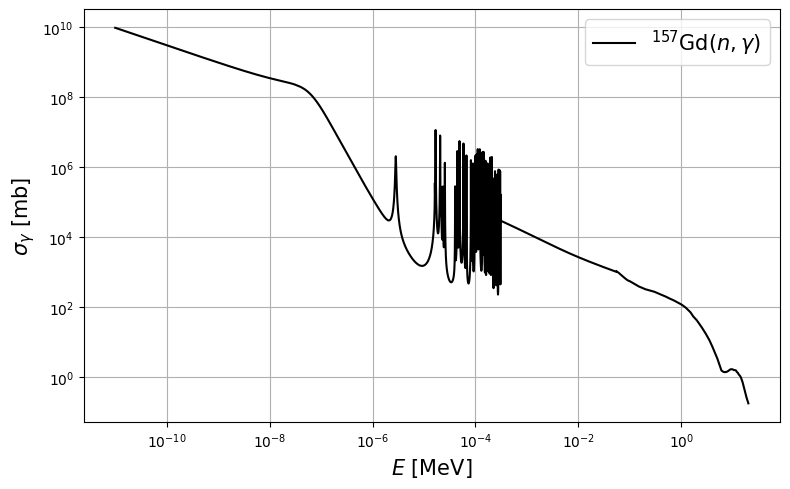

In [29]:
# Plot the ENDF cross-section data
df = gw.get_MT102(target)
plot_MT102(df,target,energy_units='MeV',cs_units='mb')
# To save the figure:
#plot_MT102(df,target,energy_units='MeV',cs_units='mb',save=True)

In [30]:
# Dump ENDF data (cross section in [b]; energy in [eV]) to CSV
df.to_csv("ng_cross_section_{0}.csv".format(target), index=False)